In [1]:
#loading and cleaning the data
import pandas as pd
import numpy as np

df = pd.read_csv("Data.csv")
df = df[df["Date"].notna()].copy()
df["Date"] = pd.to_datetime(df["Date"])
df["Timestamp"] = df["Date"] + pd.to_timedelta(df["Hour"] - 1, unit="h")
df = df.sort_values("Timestamp").reset_index(drop=True)
df = df[df["Timestamp"] < "2007-02-01"].reset_index(drop=True)

holidays = pd.read_excel("Holidays_list.xls")
holidays["Date"] = pd.to_datetime(holidays["Date"]).dt.normalize()

print(df.shape)
df.head()

(27048, 7)


,Date,Hour,DryBulb,DewPnt,SYSLoad,NumDate,Timestamp
0,2004-01-01,1.0,37.0,25.0,12230.0,732000.0,2004-01-01 00:00:00
1,2004-01-01,2.0,37.0,25.0,11534.0,732000.0,2004-01-01 01:00:00
2,2004-01-01,3.0,39.0,24.0,11038.0,732000.0,2004-01-01 02:00:00
3,2004-01-01,4.0,38.0,22.0,10777.0,732000.0,2004-01-01 03:00:00
4,2004-01-01,5.0,37.0,20.0,10764.0,732000.0,2004-01-01 04:00:00


In [2]:
#building features
df["HourOfDay"] = df["Timestamp"].dt.hour
df["DayOfWeek"] = df["Timestamp"].dt.dayofweek
df["Month"] = df["Timestamp"].dt.month
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)
df["IsHoliday"] = df["Date"].dt.normalize().isin(holidays["Date"]).astype(int)
df["DryBulb2"] = df["DryBulb"] ** 2

In [3]:
#building lag features
df["Load_Lag24"] = df["SYSLoad"].shift(24)
df["Load_Lag168"] = df["SYSLoad"].shift(168)

In [4]:
#spliting for training
train_full = df[df["SYSLoad"].notna()].copy()
forecast_target = df[df["SYSLoad"].isna()].copy()
train_full_clean = train_full.dropna(subset=["Load_Lag24", "Load_Lag168"]).copy()

internal_train = train_full_clean[train_full_clean["Timestamp"] < "2006-12-01"].copy()
internal_val = train_full_clean[(train_full_clean["Timestamp"] >= "2006-12-01") & (train_full_clean["Timestamp"] < "2007-01-01")].copy()
print("internal_train:", len(internal_train), "internal_val:", len(internal_val))

internal_train: 25392 internal_val: 744


In [5]:
#Naive baseline
naive_preds = internal_val["Load_Lag168"].values

In [6]:
#Preprocessing pipeline setup
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

numeric_features = ["DryBulb", "DryBulb2", "DewPnt", "Load_Lag24", "Load_Lag168"]
categorical_features = ["HourOfDay", "DayOfWeek", "Month", "IsWeekend", "IsHoliday"]
feature_cols = numeric_features + categorical_features

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

In [7]:
#Training and comparing all 4 approaches
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def evaluate(name, y_true, y_pred):
    return {
        "Model": name,
        "Val R2": round(r2_score(y_true, y_pred), 4),
        "Val MAE": round(mean_absolute_error(y_true, y_pred), 1),
        "Val RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 1),
        "Val MAPE%": round((abs((y_true - y_pred) / y_true)).mean() * 100, 2),
    }

results = [evaluate("Naive (last week, same hour)", internal_val["SYSLoad"], naive_preds)]
fitted = {}

for name, model in {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=40, max_depth=14, min_samples_leaf=4, random_state=42, n_jobs=2),
    "XGBoost": XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=2),
}.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipe.fit(internal_train[feature_cols], internal_train["SYSLoad"])
    fitted[name] = pipe
    results.append(evaluate(name, internal_val["SYSLoad"], pipe.predict(internal_val[feature_cols])))

results_df = pd.DataFrame(results)
results_df

,Model,Val R2,Val MAE,Val RMSE,Val MAPE%
0,"Naive (last week, same hour)",0.7943,880.9,1145.3,5.94
1,Linear Regression,0.9353,506.5,642.2,3.47
2,Random Forest,0.9373,460.5,632.4,2.98
3,XGBoost,0.9618,363.1,493.8,2.36


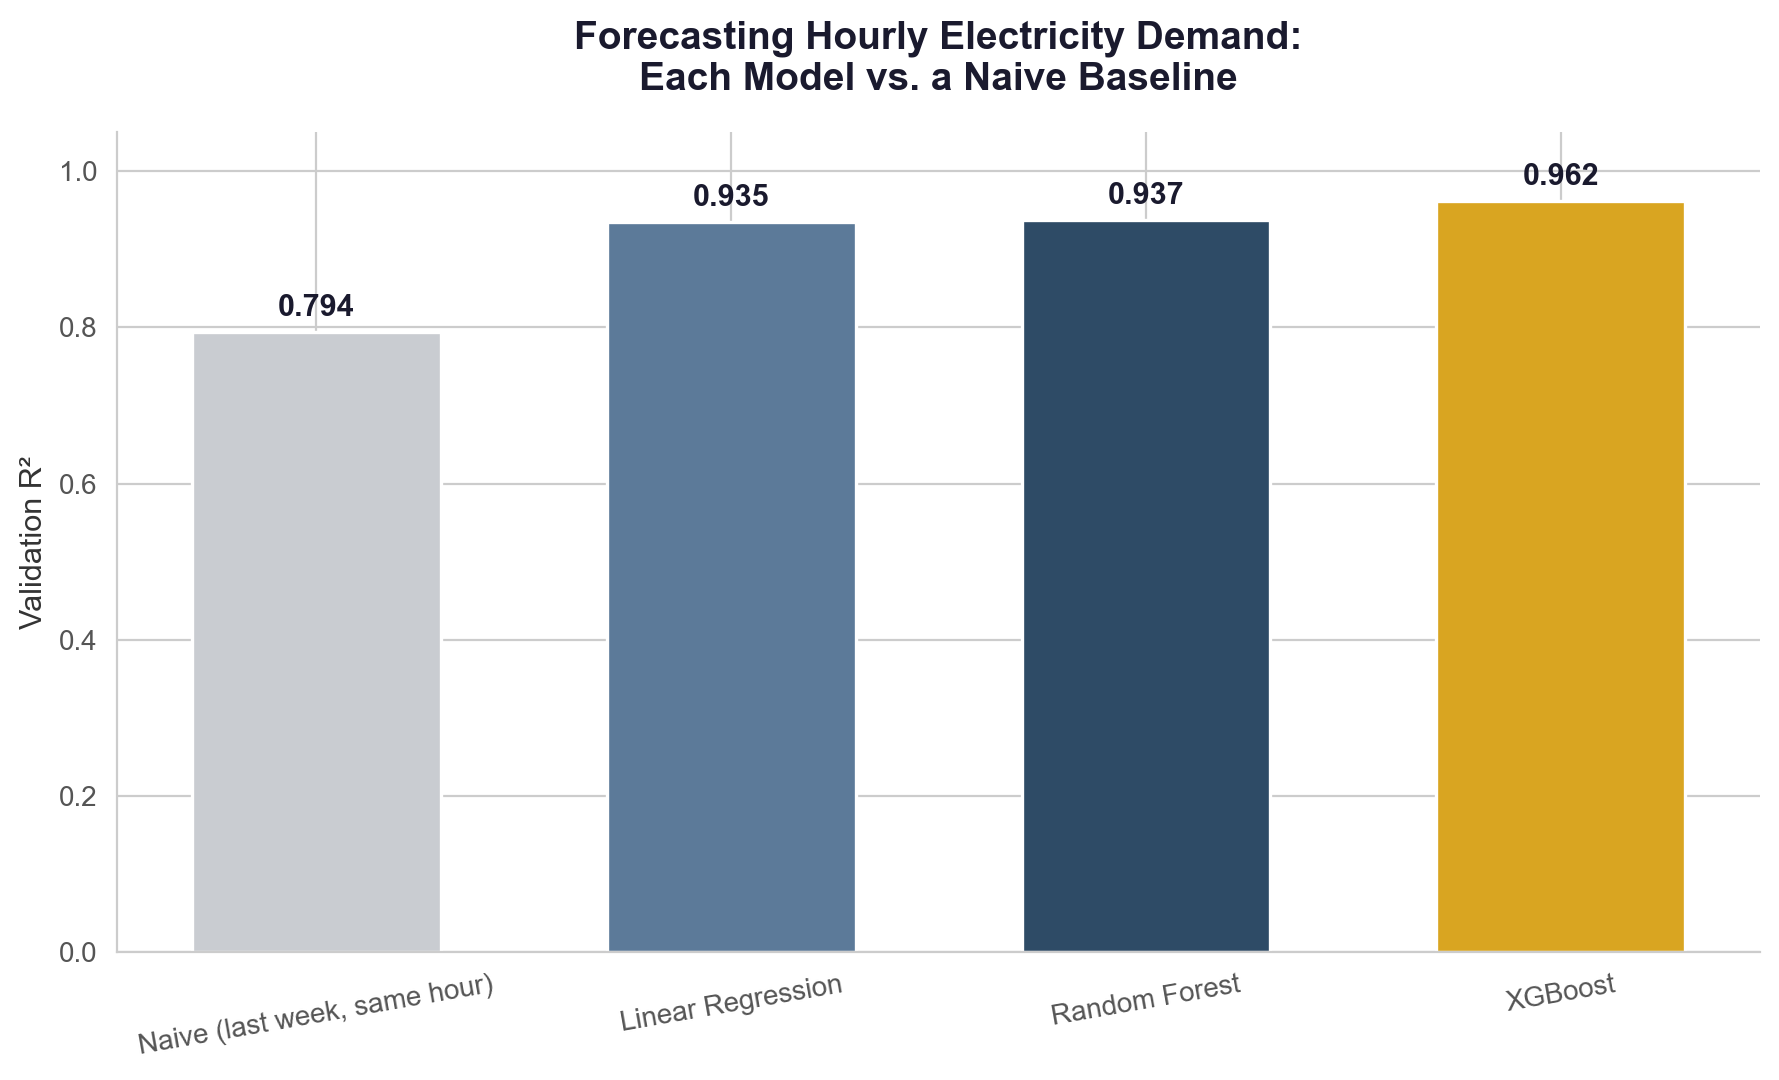

In [8]:
#Comparison bar chart
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=200)
colors = ["#C9CCD1", "#5C7A99", "#2E4B66", "#D9A521"]

bars = ax.bar(results_df["Model"], results_df["Val R2"], color=colors, width=0.6, edgecolor="white", linewidth=1.2)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Validation R²", fontsize=11, color="#333333")
ax.set_title("Forecasting Hourly Electricity Demand:\nEach Model vs. a Naive Baseline", fontsize=14, fontweight="bold", color="#1a1a2e", pad=15)

for bar, val in zip(bars, results_df["Val R2"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.3f}", ha="center", fontsize=11, fontweight="bold", color="#1a1a2e")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color("#cccccc")
ax.spines['bottom'].set_color("#cccccc")
ax.tick_params(colors="#555555")
plt.xticks(rotation=10, fontsize=10)
plt.tight_layout()
plt.savefig("model_comparison_linkedin.png", dpi=300, bbox_inches="tight")
plt.show()

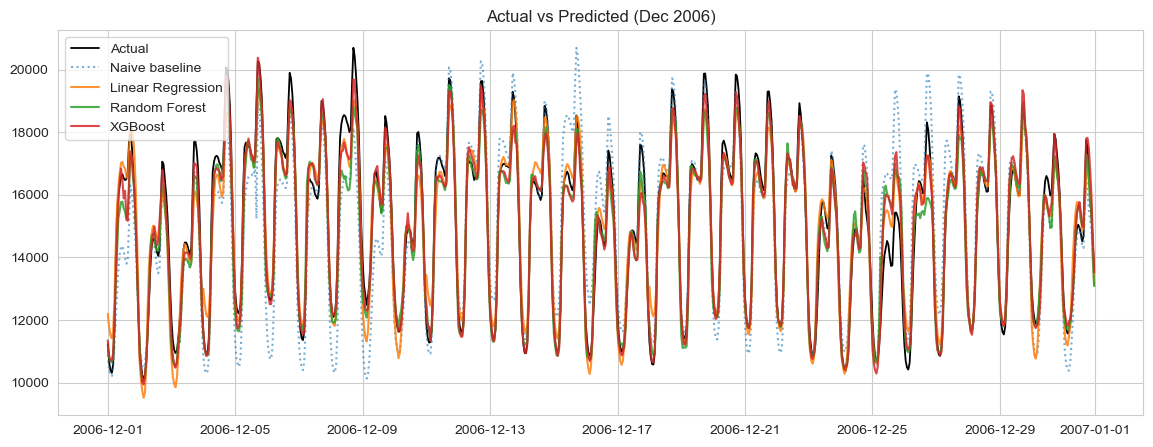

In [9]:
#Validation line chart (all models vs actual)
plt.figure(figsize=(14, 5))
plt.plot(internal_val["Timestamp"], internal_val["SYSLoad"], color="black", linewidth=1.3, label="Actual")
plt.plot(internal_val["Timestamp"], naive_preds, linestyle=":", alpha=0.6, label="Naive baseline")
for name, pipe in fitted.items():
    plt.plot(internal_val["Timestamp"], pipe.predict(internal_val[feature_cols]), alpha=0.85, label=name)
plt.legend()
plt.title("Actual vs Predicted (Dec 2006)")
plt.show()

In [10]:
#Final forecast
best_name = results_df.loc[results_df["Val R2"].idxmax(), "Model"]
print("Best model:", best_name)

final_model_map = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=40, max_depth=14, min_samples_leaf=4, random_state=42, n_jobs=2),
    "XGBoost": XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=2),
}
final_pipe = Pipeline([("preprocessor", preprocessor), ("model", final_model_map[best_name])])
final_pipe.fit(train_full_clean[feature_cols], train_full_clean["SYSLoad"])

known = train_full.set_index("Timestamp")["SYSLoad"].to_dict()
forecast_target = df[df["SYSLoad"].isna()].sort_values("Timestamp").reset_index(drop=True)
forecast_target["DateOnly"] = forecast_target["Timestamp"].dt.date

all_preds = []
for day, group in forecast_target.groupby("DateOnly", sort=True):
    g = group.copy()
    g["Load_Lag24"] = g["Timestamp"].apply(lambda ts: known.get(ts - pd.Timedelta(hours=24), np.nan))
    g["Load_Lag168"] = g["Timestamp"].apply(lambda ts: known.get(ts - pd.Timedelta(hours=168), np.nan))
    preds = final_pipe.predict(g[feature_cols])
    for ts, p in zip(g["Timestamp"], preds):
        known[ts] = p
    all_preds.extend(zip(g["Timestamp"], preds))

forecast_result = pd.DataFrame(all_preds, columns=["Timestamp", "Predicted_SYSLoad"])
print(forecast_result.shape)
forecast_result.head()

Best model: XGBoost
(744, 2)


,Timestamp,Predicted_SYSLoad
0,2007-01-01 00:00:00,12372.242188
1,2007-01-01 01:00:00,11625.792969
2,2007-01-01 02:00:00,11430.400391
3,2007-01-01 03:00:00,11509.727539
4,2007-01-01 04:00:00,11702.390625


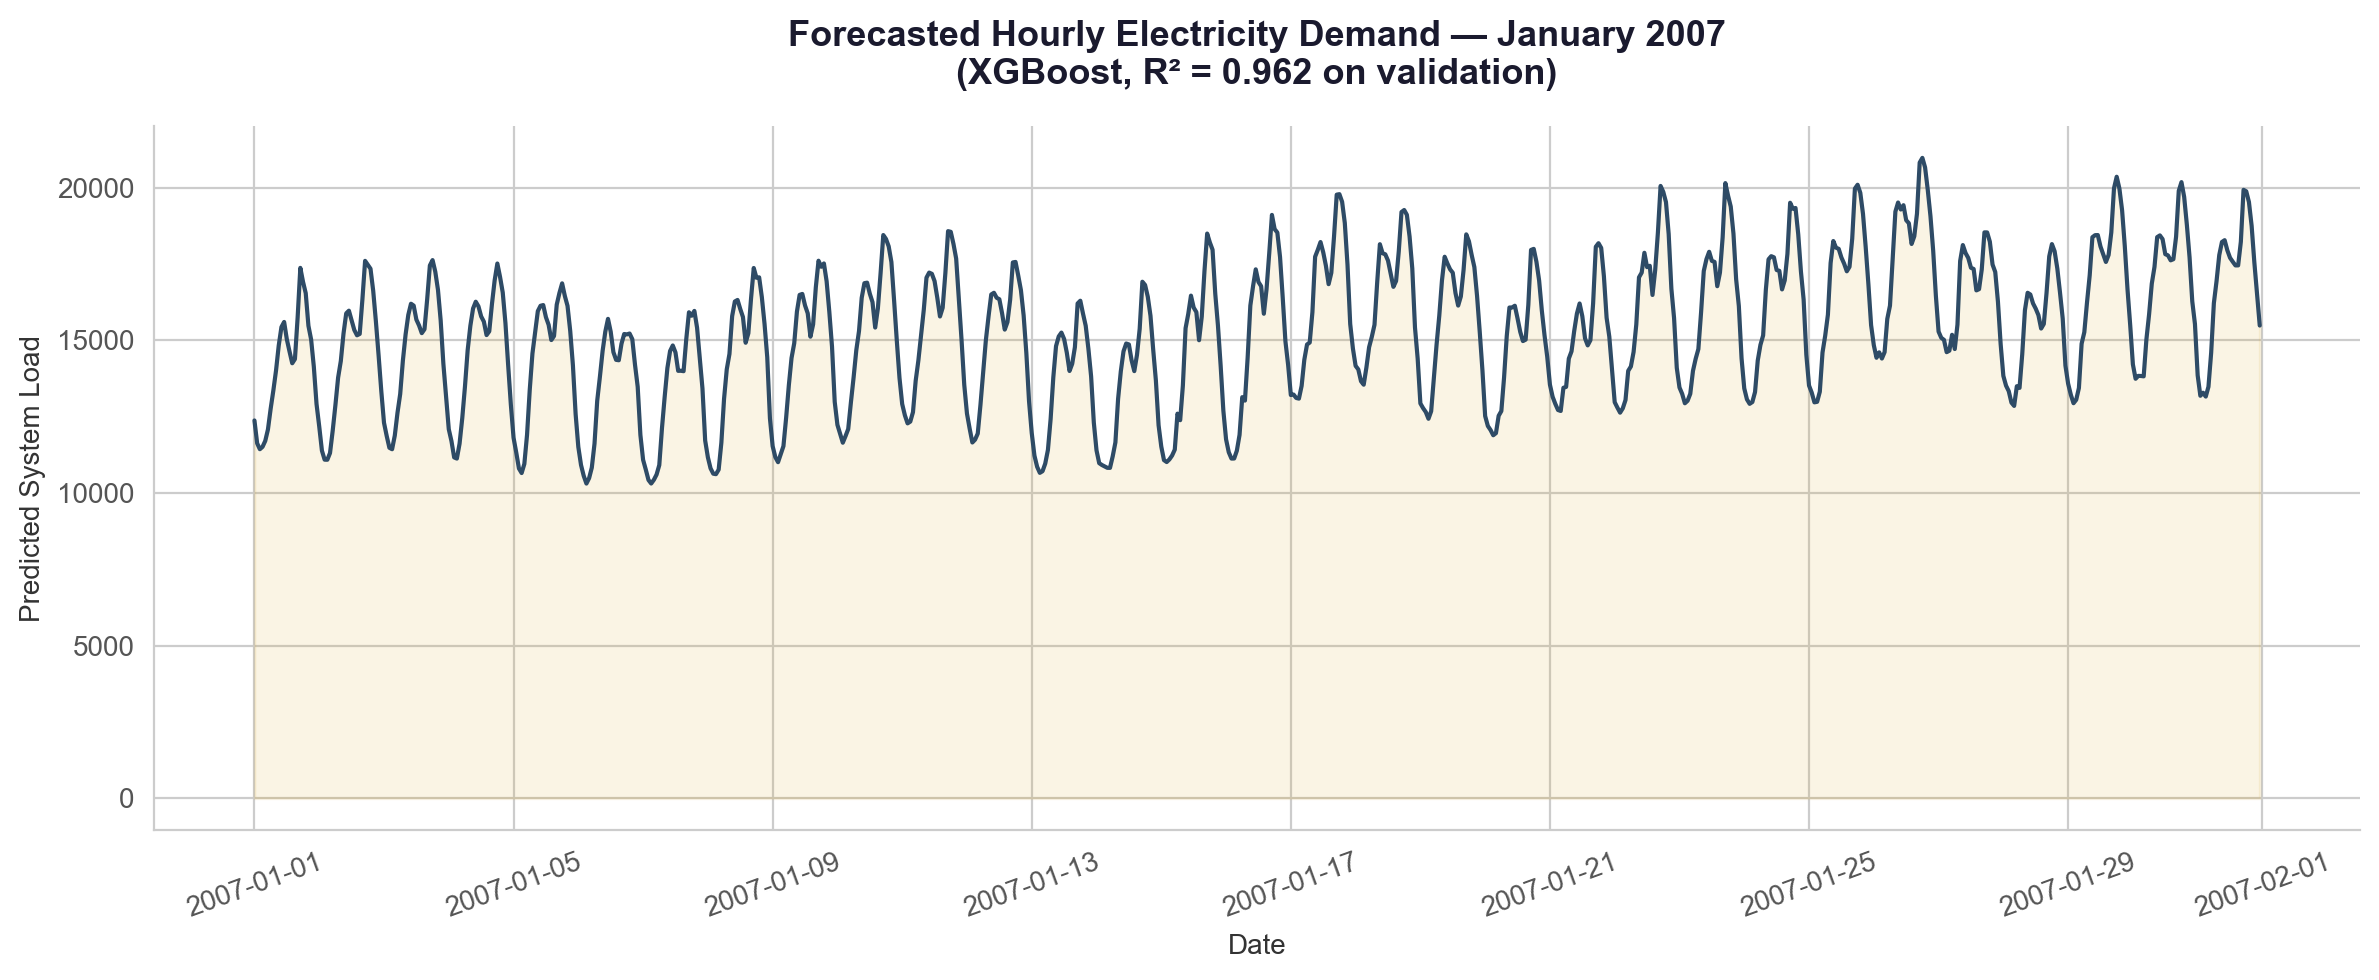

In [11]:
#Forecast chart
fig, ax = plt.subplots(figsize=(12, 5), dpi=200)
ax.plot(forecast_result["Timestamp"], forecast_result["Predicted_SYSLoad"], color="#2E4B66", linewidth=1.5)
ax.fill_between(forecast_result["Timestamp"], forecast_result["Predicted_SYSLoad"], alpha=0.12, color="#D9A521")

ax.set_title(f"Forecasted Hourly Electricity Demand — January 2007\n({best_name}, R² = {results_df['Val R2'].max():.3f} on validation)",
             fontsize=13, fontweight="bold", color="#1a1a2e", pad=15)
ax.set_xlabel("Date", color="#333333")
ax.set_ylabel("Predicted System Load", color="#333333")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color("#cccccc")
ax.spines['bottom'].set_color("#cccccc")
ax.tick_params(colors="#555555")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("january_forecast_linkedin.png", dpi=300, bbox_inches="tight")
plt.show()